## 1.Make classification data and get it ready

In [154]:
import sklearn
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt

In [155]:
#Create circles
X,y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X.shape, y.shape


((1000, 2), (1000,))

In [156]:
print(f"First 5 samples of X:\n {X[:5]},\nFirst 5 samples of y:\n  {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]],
First 5 samples of y:
  [1 1 1 1 0]


In [157]:
circles = pd.DataFrame({"X1":X[:,0],
                      "X2": X[:,1],
                      "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [158]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

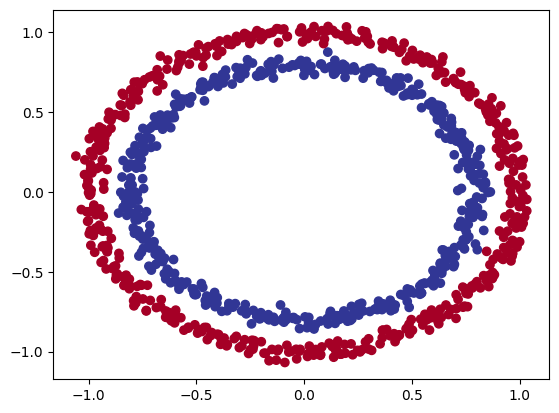

In [159]:
#visualize
plt.scatter(x=X[:,0],
           y=X[:,1],
           c=y,
           cmap=plt.cm.RdYlBu);

In [160]:
import torch
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [161]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
type(X), X.dtype

(torch.Tensor, torch.float32)

In [162]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)
len(X_train)

800

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one     
2. Construct a model (by subclassing nn.Module)     
3. Define a loss function and optimizer      
4. Create a training and test loop      

let's create a model that:

1. Subclasses nn.Module (almost all models in PyTorch subclass nn.Module)         
2. Create 2 nn.Linear() layers that are capable of handling the shapes of our data          
3. Defines a forward() method that outlines the forward pass (or forward computation) of the model         
4. Instatiate an instance of our model class and send it to the target device        

In [163]:
from torch import nn

# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

         # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5)   # takes in 2 features and upscales to 5 features 
        self.layer_2 = nn.Linear(in_features=5, out_features=1)   # takes in 5 features from previous layer and outputs a single feature (same shape as y)

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x))     # x -> layer_1 ->  layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0()
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [164]:
# Let's replicate the model above using nn.Sequential()
model_0 =nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
)
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2238, -0.0764],
                      [-0.1642,  0.0447],
                      [ 0.6509, -0.6550],
                      [-0.2946, -0.1298],
                      [ 0.1136,  0.0008]])),
             ('0.bias', tensor([-0.4564,  0.0317,  0.1962,  0.6927, -0.5392])),
             ('1.weight',
              tensor([[ 0.3442,  0.3467,  0.1284, -0.1128, -0.1316]])),
             ('1.bias', tensor([-0.3964]))])

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?        
Again... this is problem specific.           
For example for regression you might want MAE or MSE (mean absolute error or mean squared error).           
For classification you might want binary cross entropy or categorical cross entropy (cross entropy).          
As a reminder, the loss function measures how wrong your models predictions are.           
And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.   

In [165]:
#Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = requires inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss()   # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [166]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right? 
def accuracy_fn(y_true, y_pred):
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)
    correct = (y_true == y_pred).sum().item()
    return (correct/y_pred.shape[0]) * 100

## 3. Train model       
To train our model, we're going to need to build a training loop with the following steps:          
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels
Our model outputs are going to be raw logits.       
We can convert these logits into prediction probabilities by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).      
Then we can convert our model's prediction probabilities to prediction labels by either rounding them or taking the argmax().

In [167]:
y_pred_label = torch.round(torch.sigmoid(model_0(X_test)[:5]))
y_pred_label.squeeze()

tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

**Why apply sigmoid first?**         
	•	Logits are in the range (-∞, +∞), so they are not probabilities.        
	•	sigmoid(logit) maps values to (0, 1), which can be interpreted as probabilities.       
	•	For binary classification, a natural decision threshold is 0.5:      
	•	probability ≥ 0.5 → class 1        
	•	probability < 0.5 → class 0         

So the usual flow is: logits → sigmoid → probability → threshold (0.5) → label.       

### 3.2 Building a training and testing loop

In [168]:
# Build training and evaluation loop
epochs = 100
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))   # turn logits -> pred probs -> pred labels
    
    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)   # nn.BCEWithLogitsLoss expects raw logits as input
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass 
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happenin'
    if epoch%10==0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 0.72782, Acc: 50.00% | Test loss: 0.72248, Test acc: 50.00%
Epoch: 10 | Loss: 0.70505, Acc: 50.00% | Test loss: 0.70155, Test acc: 50.00%
Epoch: 20 | Loss: 0.69777, Acc: 50.00% | Test loss: 0.69473, Test acc: 50.00%
Epoch: 30 | Loss: 0.69541, Acc: 44.25% | Test loss: 0.69251, Test acc: 45.50%
Epoch: 40 | Loss: 0.69461, Acc: 45.75% | Test loss: 0.69180, Test acc: 51.00%
Epoch: 50 | Loss: 0.69428, Acc: 47.75% | Test loss: 0.69160, Test acc: 52.00%
Epoch: 60 | Loss: 0.69412, Acc: 47.88% | Test loss: 0.69158, Test acc: 52.00%
Epoch: 70 | Loss: 0.69401, Acc: 48.25% | Test loss: 0.69161, Test acc: 54.00%
Epoch: 80 | Loss: 0.69392, Acc: 47.75% | Test loss: 0.69168, Test acc: 54.50%
Epoch: 90 | Loss: 0.69385, Acc: 48.38% | Test loss: 0.69175, Test acc: 55.00%


## 4. Make predictions and evaluate the model        
From the metrics it looks like our model isn't learning anything...       
So to inspect it let's make some predictions and make them visual!       
In other words, "Visualize, visualize, visualize!"       

To do so, we're going to import a function called plot_decision_boundary() - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

In [169]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exist, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exist, skipping download


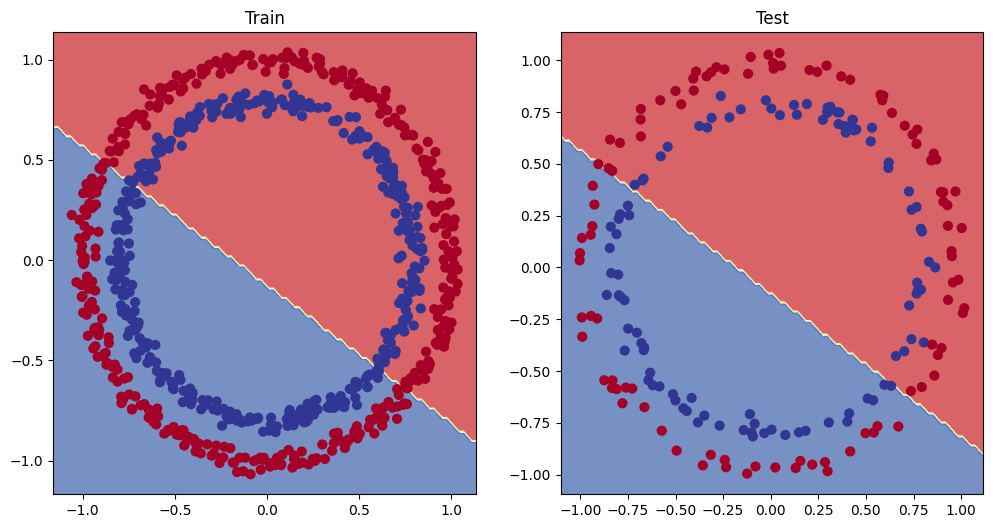

In [170]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from a model perspective)

- Add more layers - give the model more chances to learn about patterns in the data    
- Add more hidden units - go from 5 hidden units to 10 hidden units        
- Fit for longer      
- Changing the activation functions         
- Change the learning rate      
- Change the loss function        
- These options are all from a model's perspective because they deal directly with the model, rather than the data.     

And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred as  **hyperparameters**.      

Let's try and improve our model by:     

1. Adding more hidden units: 5 -> 10     
2. Increase the number of layers: 2 -> 3      
3. Increase the number of epochs: 100 -> 1000    

In [171]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [172]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr = 0.1)

In [173]:
epochs = 1000
for epoch in range(epochs):
    model_1.train()
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch%100==0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69582, Acc: 50.00% | Test loss: 0.80670, Test acc: 50.00%
Epoch: 100 | Loss: 0.69298, Acc: 51.38% | Test loss: 0.69473, Test acc: 46.00%
Epoch: 200 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 400 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.12% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Acc: 51.25% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%


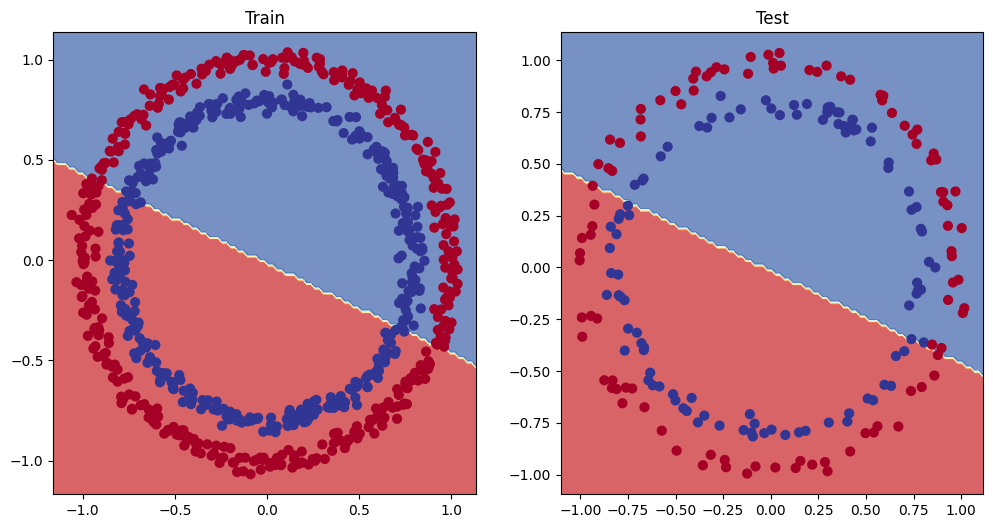

In [174]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test) 

### 5.1 Preparing data to see if our model can fit a straight line      
One way to troubleshoot to a larger problem is to test out a smaller problem.

In [175]:
weight = 0.7
bias = 0.3
x_reg = torch.arange(0, 1, 0.01).unsqueeze(dim=1)
y_reg = weight * x_reg + bias

print(len(x_reg))
x_reg[:5], y_reg[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

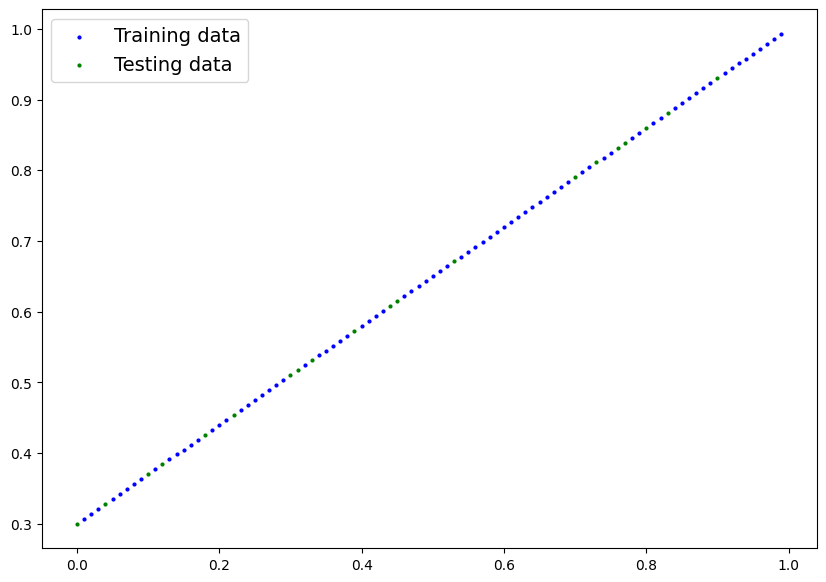

In [176]:
x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(x_reg, y_reg, train_size=0.8, random_state=42)
plot_predictions(train_data = x_reg_train,
                train_labels = y_reg_train,
                test_data = x_reg_test,
                test_labels = y_reg_test)


### 5.2 Adjusting model_1 to fit a straight line

In [177]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [178]:
# Loss and optimizer
loss_fn = nn.L1Loss()   # MAE loss with regression data
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [179]:
# Train the model
epochs = 1000
for epoch in range(epochs):
    model_2.train()
    y_pred = model_2(x_reg_train).squeeze()
    loss = loss_fn(y_pred, y_reg_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(x_reg_test).squeeze()
        test_loss = loss_fn(test_pred, y_reg_test)

    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.54536 | Test loss: 0.48207
Epoch: 100 | Loss: 0.18642 | Test loss: 0.18621
Epoch: 200 | Loss: 0.17723 | Test loss: 0.18164
Epoch: 300 | Loss: 0.17460 | Test loss: 0.18167
Epoch: 400 | Loss: 0.17387 | Test loss: 0.18185
Epoch: 500 | Loss: 0.17368 | Test loss: 0.18177
Epoch: 600 | Loss: 0.17361 | Test loss: 0.18180
Epoch: 700 | Loss: 0.17360 | Test loss: 0.18192
Epoch: 800 | Loss: 0.17360 | Test loss: 0.18192
Epoch: 900 | Loss: 0.17360 | Test loss: 0.18192


/Users/deryaakgun/Library/Python/3.11/lib/python/site-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([80, 1])) that is different to the input size (torch.Size([80])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/Users/deryaakgun/Library/Python/3.11/lib/python/site-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


## 6. The missing piece: non-linearity
"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"        
Or in machine learning terms, an infinite (but really it is finite) of linear and non-linear functions?   

### 6.1 Recreating non-linear data (red and blue circles)

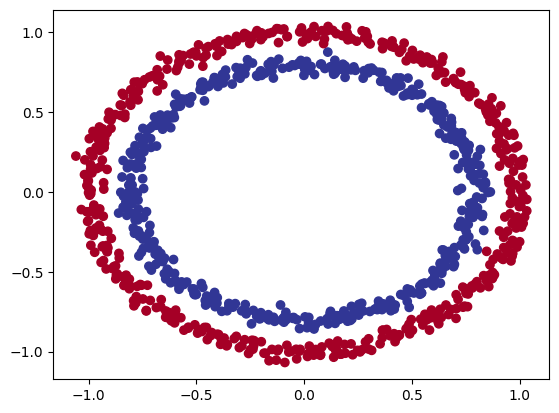

In [190]:
X,y = make_circles(1000, noise=0.03, random_state=42)
plt.scatter(x=X[:,0],
           y=X[:,1],
           c=y,
           cmap=plt.cm.RdYlBu);

In [191]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

- Linear = straight lines      
- Non-linear = non-straight lines         
Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [192]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2()
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [193]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity

In [194]:
epochs = 1000
for epoch in range(epochs):
    model_2.train()
    y_pred = model_2(X_train).squeeze()
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test).squeeze()
        test_loss = loss_fn(test_pred, y_test)

    if epoch%100 == 0:
        print(f"Epoch: {epoch}  |  Train Loss: {loss:.5f}  |  Test Loss: {test_loss:.5f}")

Epoch: 0  |  Train Loss: 0.69451  |  Test Loss: 0.69353
Epoch: 100  |  Train Loss: 0.69188  |  Test Loss: 0.69112
Epoch: 200  |  Train Loss: 0.69054  |  Test Loss: 0.68992
Epoch: 300  |  Train Loss: 0.68889  |  Test Loss: 0.68864
Epoch: 400  |  Train Loss: 0.68676  |  Test Loss: 0.68691
Epoch: 500  |  Train Loss: 0.68356  |  Test Loss: 0.68441
Epoch: 600  |  Train Loss: 0.67879  |  Test Loss: 0.68040
Epoch: 700  |  Train Loss: 0.67139  |  Test Loss: 0.67406
Epoch: 800  |  Train Loss: 0.65950  |  Test Loss: 0.66387
Epoch: 900  |  Train Loss: 0.64007  |  Test Loss: 0.64637
